In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from scipy import stats
from glob import glob
import torch.nn.functional as F
import torch

In [225]:
FILTER_SE_GENES = False # filter for only genes with SE events
SINGLE_COUNT_GENES = True # average out predictions per gene_id
HURDLE_SEPARATION = False # separate 1 values from the rest of the psi predictions
NORMALISED_SCORES = False # show uncorrected scores when they were z-score normalised

In [226]:
def get_predictions(date_folder):
    # find .csv file in the date folder
    csv_files = [f for f in glob(f"trained_models/{date_folder}/*.csv") if not f.endswith('losses.csv')]
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {date_folder}")
    if len(csv_files) == 1:
        return pd.read_csv(csv_files[0])
    else:
        all_predictions = []
        for pred_file in csv_files:
            df = pd.read_csv(pred_file)
            if 'Unnamed: 0' in df.columns:
                df = df.drop(columns=['Unnamed: 0'])
            all_predictions.append(df)
        return pd.concat(all_predictions, ignore_index=True)
    

In [227]:
predictions = get_predictions('2025-06-26-19') # change here to the folder name you want to load
predictions = predictions.rename(columns={'Unnamed: 0': 'gene_id'})
predictions

,gene_id,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx
0,ENSG00000196388,1.305116,-0.823909,0.791942,1.0,1
1,ENSG00000164051,1.398647,1.109916,0.909861,1.0,1
2,ENSG00000064102,0.941664,1.707059,0.913182,1.0,1
3,ENSG00000064102,1.008789,1.707059,0.880655,1.0,1
4,ENSG00000064102,1.001174,1.707059,0.837978,1.0,1
...,...,...,...,...,...,...
2480,ENSG00000106397,0.977185,1.317646,0.912361,1.0,1
2481,ENSG00000106397,0.963881,1.317646,0.919078,1.0,1
2482,ENSG00000106397,1.003788,1.317646,0.920501,1.0,1
2483,ENSG00000134769,0.012571,0.045323,0.934033,1.0,1


In [228]:
if FILTER_SE_GENES:
    # filter predictions to the ones we have SE events for
    se_events = pd.read_csv('data/psi_response.csv')
    se_events = se_events[se_events['event_id'].str.contains(';SE:')]
    se_genes = set(se_events['gene_id'].unique())

    # filter down predictions to only those genes
    predictions_filtered = predictions[predictions['gene_id'].isin(se_genes)]
    len(predictions_filtered)

In [229]:
if SINGLE_COUNT_GENES:
    # filter the predictions such that for one gene, we average out the predictions
    if FILTER_SE_GENES:
        predictions_filtered = predictions_filtered.groupby('gene_id').mean().reset_index()
    else:
        predictions_filtered = predictions.drop_duplicates(subset=['gene_id'], keep='first')

In [230]:
if not FILTER_SE_GENES and not SINGLE_COUNT_GENES:
    predictions_filtered = predictions

In [231]:
def plot_predictions(predictions, cell_line, pred_col, actual_col):
    pearsonR, _ = stats.pearsonr(predictions[pred_col], predictions[actual_col])
    r2_value = r2_score(predictions[actual_col], predictions[pred_col])
    plt.figure(figsize=(6,6))
    ax = sns.jointplot(
        data=predictions,
        x=pred_col,
        y=actual_col,
        kind = 'scatter',
        joint_kws={'marker':'o', 's':10, 'alpha':0.5, 'linewidth':0},
        marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
    )
    prediction_task = 'PSI' if 'Psi' in pred_col else 'Expression'
    ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
    plt.title(f"{cell_line} {prediction_task} Pred (Pearson R: {pearsonR:.2f}, R²: {r2_value:.2f}, n={len(predictions)})")
    plt.ylabel(f'{cell_line} {prediction_task} (actual)')
    plt.xlabel(f'{cell_line} {prediction_task} (predicted)')
    #if prediction_task == 'PSI':
    #    plt.xlim(-0.1, 1.1)
    #    plt.ylim(-0.1, 1.1)
    #else:
    #    plt.xlim(-1, 5)
    #    plt.ylim(-1, 5)
    plt.tight_layout()
    
def plot_confusion_matrix(predictions, cell_line, pred_col, actual_col):
    confusion_matrix = pd.crosstab(predictions[pred_col], predictions[actual_col])
    
    plt.figure(figsize=(6,6))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{cell_line} Confusion Matrix")
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.tight_layout()

<Figure size 600x600 with 0 Axes>

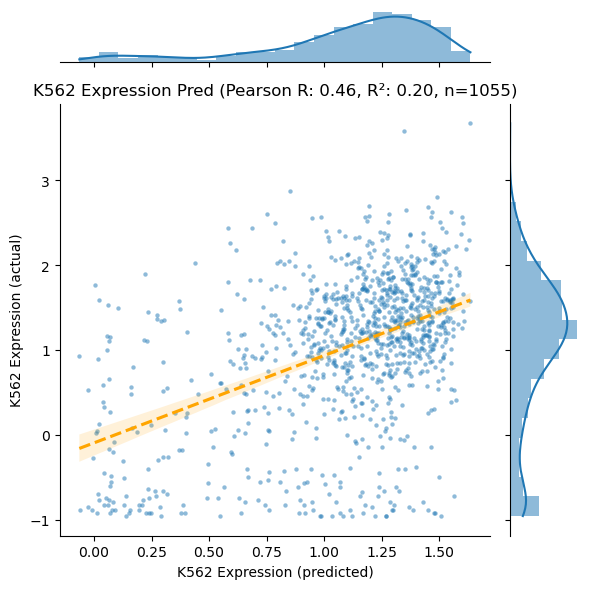

In [232]:
plot_predictions(predictions_filtered, cell_line='K562', pred_col='PredExpr', actual_col='ActualExpr')
plt.show()

In [233]:
predictions_psi_filtered = None
binary_predictions = None
if HURDLE_SEPARATION:
    binary_predictions = predictions.copy()
    # convert all numbers that are not 1 to zero
    binary_predictions['PredPsi'] = np.where(binary_predictions['PredPsi'] == 1, "1", "0-0.99")
    binary_predictions['ActualPsi'] = np.where(binary_predictions['ActualPsi'] == 1, "1", "0-0.99")

    # predictions_psi_filtered = predictions[binary_predictions['ActualPsi'] != "1"].copy()
    predictions_psi_filtered = predictions[(predictions['PredPsi'] != 1) & (predictions['ActualPsi'] != 1)].copy()

<Figure size 600x600 with 0 Axes>

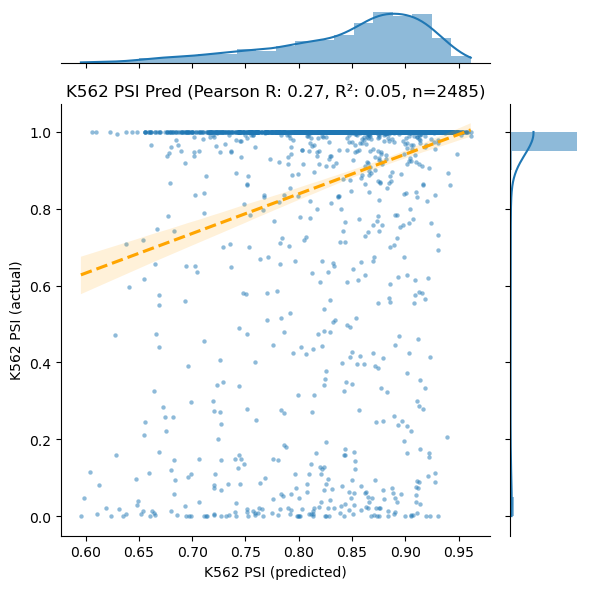

In [234]:
if binary_predictions is not None:
    plot_confusion_matrix(binary_predictions, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')
    plt.show()

if predictions_psi_filtered is None:
    predictions_psi_filtered = predictions.copy()
plot_predictions(predictions_psi_filtered, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')
plt.show()

In [235]:
if NORMALISED_SCORES:
    plot_predictions(predictions_filtered, cell_line='K562', pred_col='UncorrPredPsi', actual_col='UncorrActualPsi')
    plt.show()
    plot_predictions(predictions_filtered, cell_line='K562', pred_col='UncorrPredExpr', actual_col='UncorrActualExpr')
    plt.show()

## Check how similar predictions for the same genes are 

In [236]:
# filter for rows where gene_id appears more than once
predictions_multiple = predictions[predictions.duplicated(subset=['gene_id'], keep=False)]
predictions_multiple

,gene_id,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx
2,ENSG00000064102,0.941664,1.707059,0.913182,1.000000,1
3,ENSG00000064102,1.008789,1.707059,0.880655,1.000000,1
4,ENSG00000064102,1.001174,1.707059,0.837978,1.000000,1
5,ENSG00000117533,1.528649,1.129690,0.862527,1.000000,1
6,ENSG00000117533,1.532760,1.129690,0.714395,1.000000,1
...,...,...,...,...,...,...
2477,ENSG00000149257,1.429203,1.830139,0.665362,0.003889,1
2479,ENSG00000106397,1.023376,1.317646,0.906336,1.000000,1
2480,ENSG00000106397,0.977185,1.317646,0.912361,1.000000,1
2481,ENSG00000106397,0.963881,1.317646,0.919078,1.000000,1


In [237]:
predictions_multiple['index'] = predictions_multiple.groupby('gene_id').cumcount()
predictions_multiple

/tmp/ipykernel_2953143/27208789.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictions_multiple['index'] = predictions_multiple.groupby('gene_id').cumcount()


,gene_id,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx,index
2,ENSG00000064102,0.941664,1.707059,0.913182,1.000000,1,0
3,ENSG00000064102,1.008789,1.707059,0.880655,1.000000,1,1
4,ENSG00000064102,1.001174,1.707059,0.837978,1.000000,1,2
5,ENSG00000117533,1.528649,1.129690,0.862527,1.000000,1,0
6,ENSG00000117533,1.532760,1.129690,0.714395,1.000000,1,1
...,...,...,...,...,...,...,...
2477,ENSG00000149257,1.429203,1.830139,0.665362,0.003889,1,3
2479,ENSG00000106397,1.023376,1.317646,0.906336,1.000000,1,0
2480,ENSG00000106397,0.977185,1.317646,0.912361,1.000000,1,1
2481,ENSG00000106397,0.963881,1.317646,0.919078,1.000000,1,2


In [238]:
summary = (
    predictions_multiple
    .groupby('gene_id')['PredExpr']
    .agg(['min', 'max', 'mean'])
    .assign(range=lambda x: x['max'] - x['min'])
    .sort_values('mean', ascending=False)
    .reset_index()
)
summary

,gene_id,min,max,mean,range
0,ENSG00000111678,1.631436,1.661704,1.649156,0.030267
1,ENSG00000205758,1.585605,1.637187,1.615628,0.051582
2,ENSG00000196262,1.523278,1.664562,1.615326,0.141285
3,ENSG00000136450,1.601904,1.626307,1.614105,0.024403
4,ENSG00000178952,1.597698,1.615569,1.606633,0.017871
...,...,...,...,...,...
657,ENSG00000147168,-0.004321,0.019665,0.004611,0.023986
658,ENSG00000140795,-0.025860,0.036088,-0.005063,0.061948
659,ENSG00000138615,-0.068825,-0.008688,-0.038756,0.060137
660,ENSG00000166321,-0.077608,-0.023195,-0.046796,0.054412


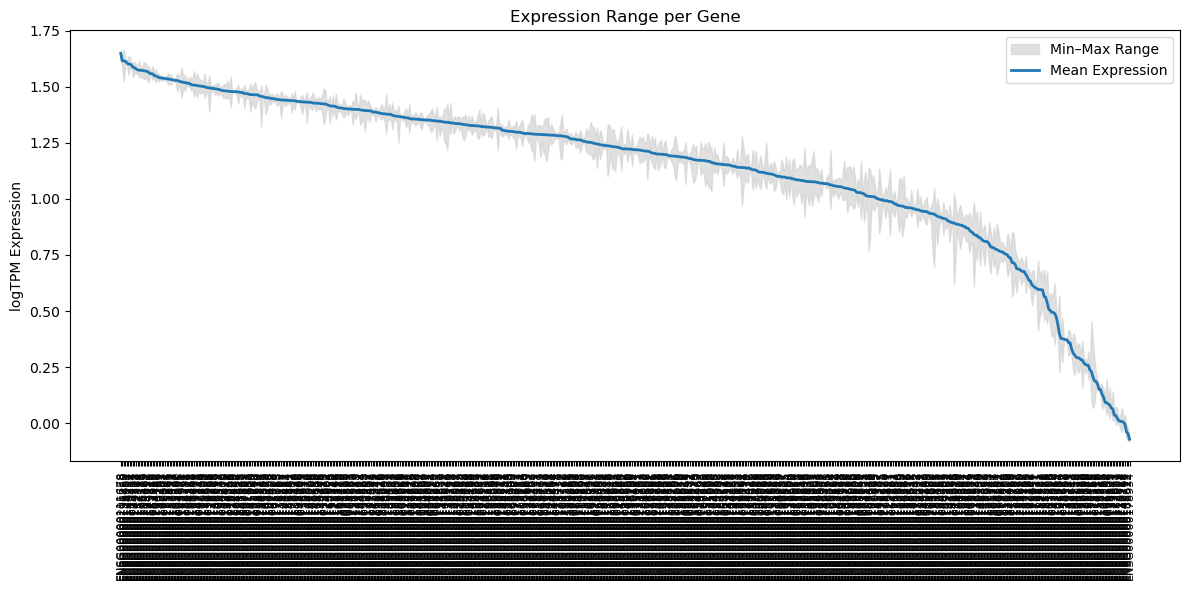

In [239]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(summary))

# Shaded area for min-max range
ax.fill_between(x, summary['min'], summary['max'], color='lightgray', alpha=0.7, label='Min–Max Range')

# Line for the mean
ax.plot(x, summary['mean'], linewidth=2, label='Mean Expression')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(summary['gene_id'], rotation=90, fontsize=8)
ax.set_ylabel("logTPM Expression")
ax.set_title("Expression Range per Gene")
ax.legend()
plt.tight_layout()
plt.show()